In [1]:
import pandas as pd
import numpy as np

In [2]:
df_ai_sig_embeddings = pd.read_csv("../results/pathway/weighted_pca_10pcs_scores.csv", index_col=0)
df_plain_embeddings = pd.read_csv("../results/GSE95640_PCA_100components_with_classification.csv", index_col=0)
df_sig_plain_embeddings = pd.read_csv("../results/GSE95640_Significant_80_genes_PCA_26_components_with_classification.csv", index_col=0)
df_sig_plain_embeddings = df_sig_plain_embeddings[df_sig_plain_embeddings.columns[:20].tolist() + ["group", "group_0_1"]]
df_sig_de_genes = pd.read_csv("../results/80_significant_genes_all_normalized_counts_with_groups.csv", index_col=0)


Random Forest Classification Comparison - Embedding Methods

1. Analysis: Agentic AI Embedding on Sig Genes
------------------------------------------------
Features: 10 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy: 0.9091 (90.9%)
AUC: 0.9325

Classification Report:
Precision: 0.9115
Recall: 0.9091
F1-Score: 0.9089

Confusion Matrix:
True Negatives: 37, False Positives: 2
False Negatives: 5, True Positives: 33

2. Analysis: Plain Embedding on All Genes
-------------------------------------------
Features: 100 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy: 0.6494 (64.9%)
AUC: 0.7483

Classification Report:
Precision: 0.6513
Recall: 0.6494
F1-Score: 0.6476

Confusion Matrix:
True Negatives: 28, False Positives: 11
False Negatives: 16, True Positives: 22

3. Analysis: Plain Embedding on Sig Genes
-------------------------------------------
Features: 20 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy: 0.8052 (80.5%)
AUC: 0.8758

Classificat

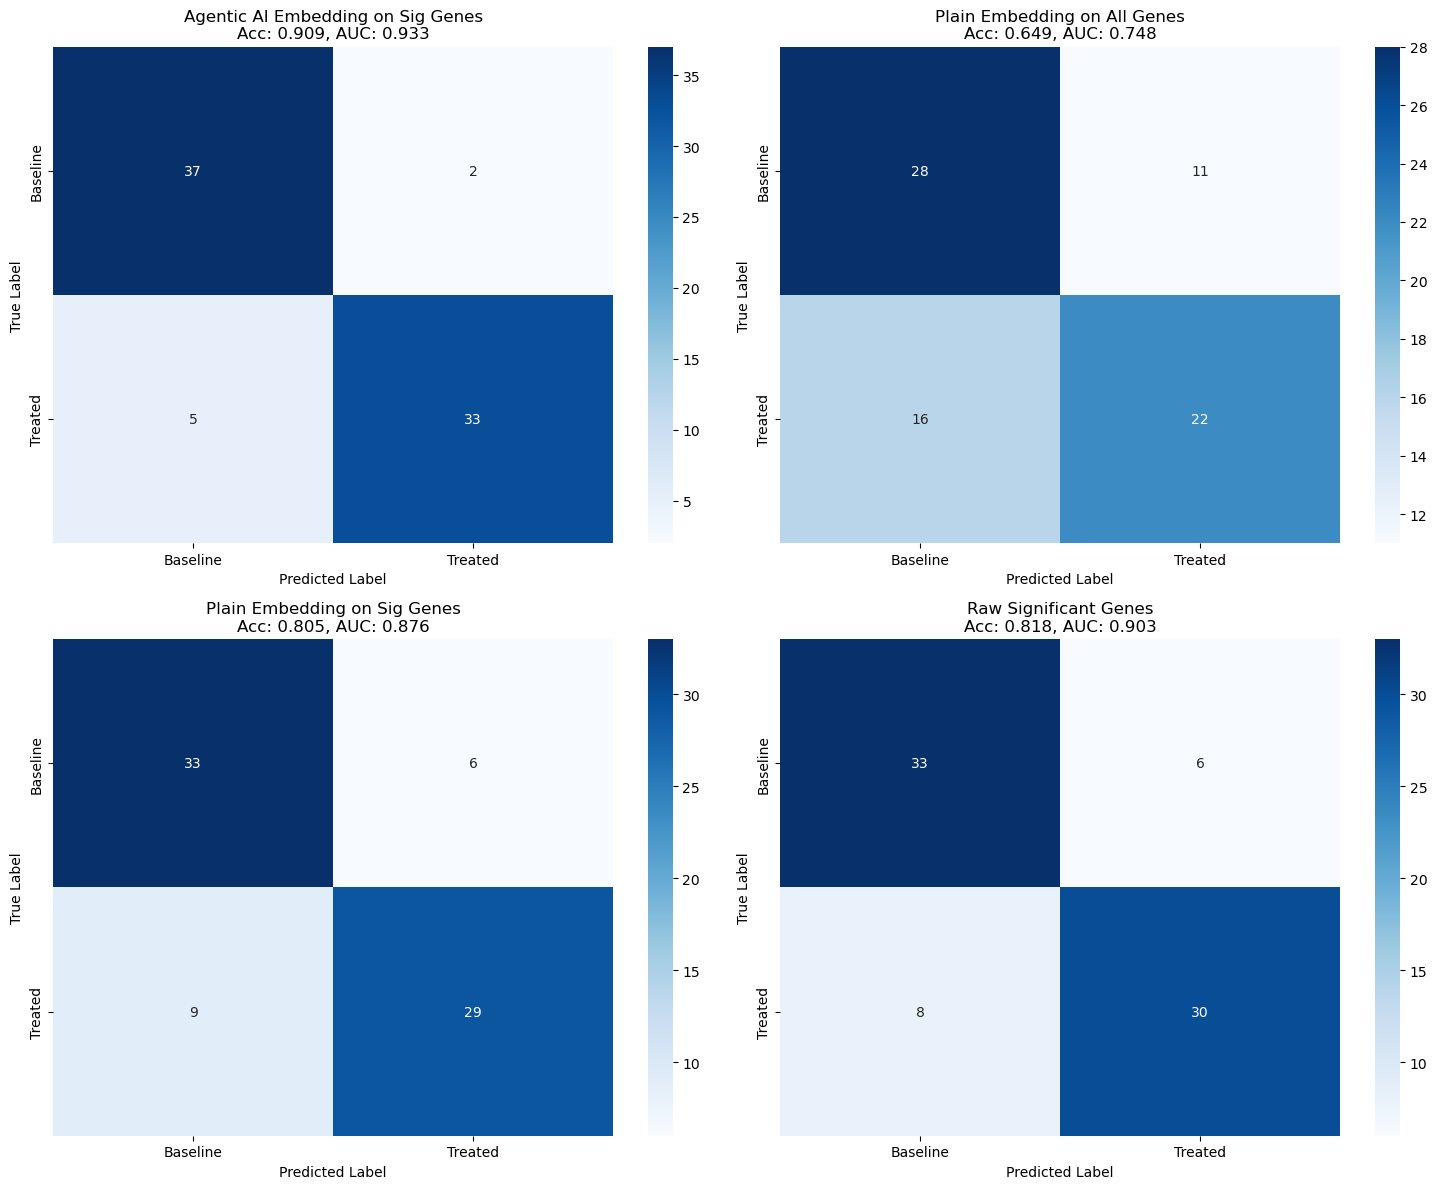


SUMMARY COMPARISON - EMBEDDING METHODS
Random Forest Classification Comparison - Embedding Methods

1. Analysis: Agentic AI Embedding on Sig Genes
------------------------------------------------
Features: 10 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy: 0.9091 (90.9%)
AUC: 0.9325

Classification Report:
Precision: 0.9115
Recall: 0.9091
F1-Score: 0.9089

Confusion Matrix:
True Negatives: 37, False Positives: 2
False Negatives: 5, True Positives: 33

2. Analysis: Plain Embedding on All Genes
-------------------------------------------
Features: 100 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy: 0.6494 (64.9%)
AUC: 0.7483

Classification Report:
Precision: 0.6513
Recall: 0.6494
F1-Score: 0.6476

Confusion Matrix:
True Negatives: 28, False Positives: 11
False Negatives: 16, True Positives: 22

3. Analysis: Plain Embedding on Sig Genes
-------------------------------------------
Features: 20 dimensions
Samples: 382 (Baseline: 191, Treated: 191)
Accuracy:

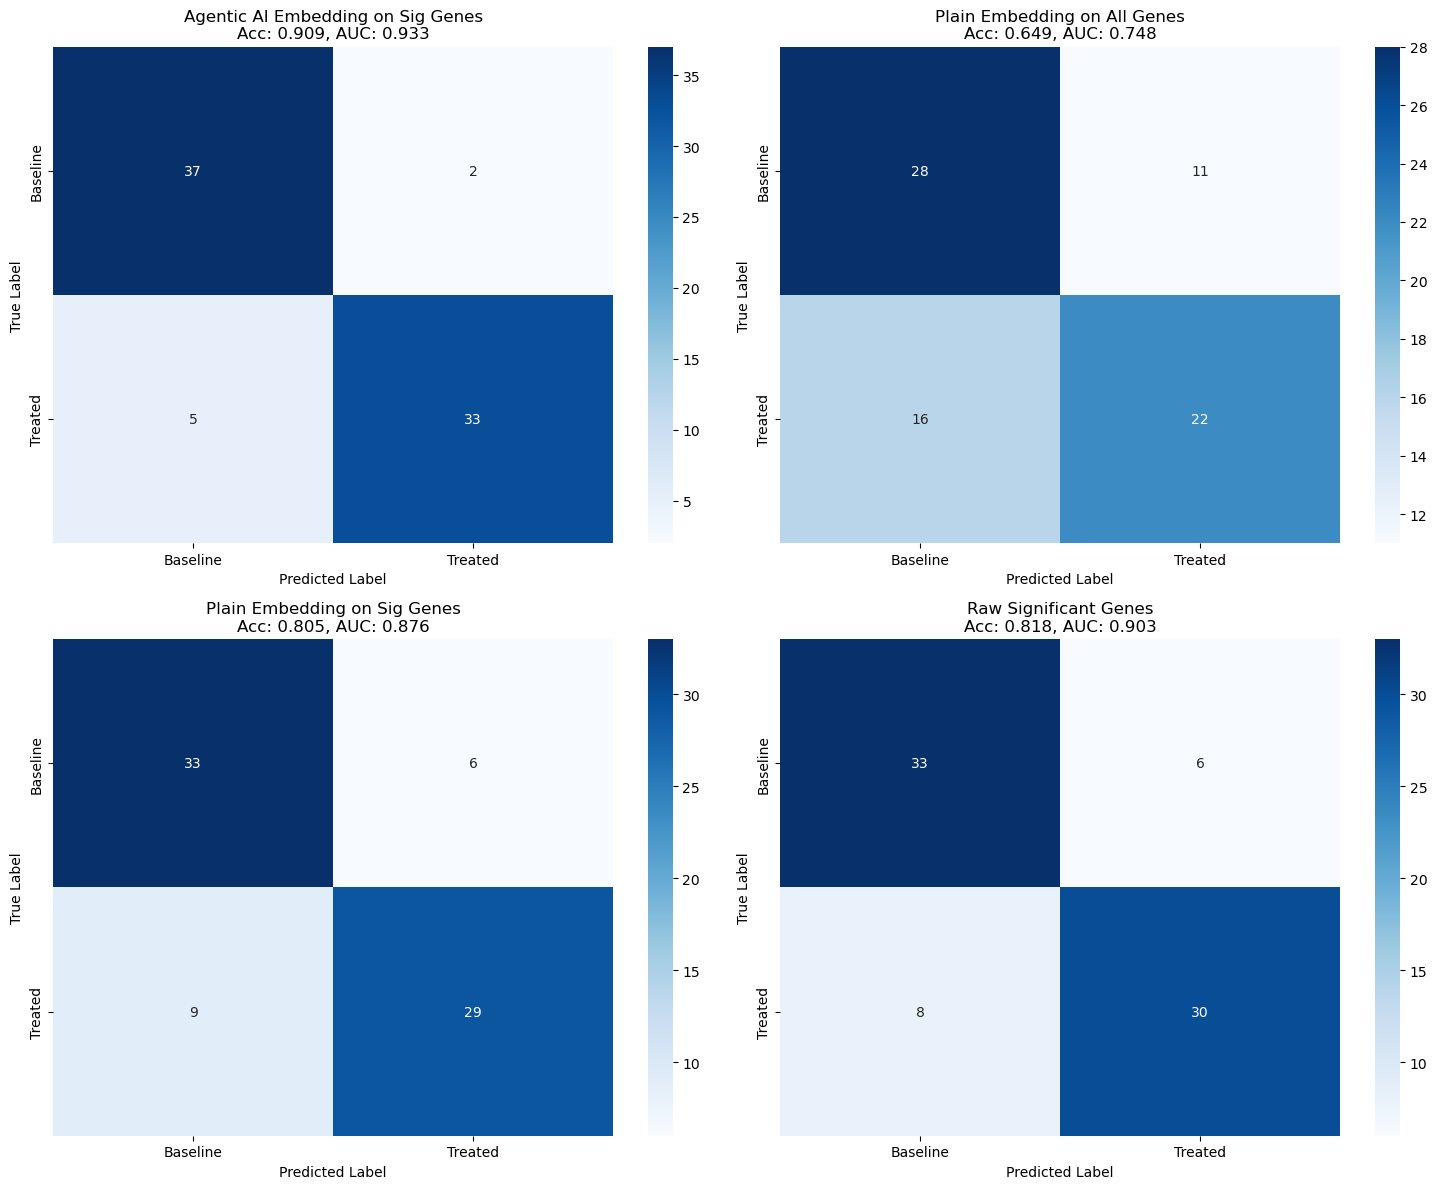


SUMMARY COMPARISON - EMBEDDING METHODS


In [3]:
# Comprehensive Random Forest Classification Comparison
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Random Forest Classification Comparison - Embedding Methods")
print("=" * 60)

# Define datasets and their names
datasets = {
    'Agentic AI Embedding on Sig Genes': df_ai_sig_embeddings,
    'Plain Embedding on All Genes': df_plain_embeddings, 
    'Plain Embedding on Sig Genes': df_sig_plain_embeddings,
    'Raw Significant Genes': df_sig_de_genes
}

# Storage for results
results = {}
roc_data = {}

# Set up plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, df) in enumerate(datasets.items()):
    print(f"\n{idx+1}. Analysis: {name}")
    print("-" * (len(name) + 15))
    
    # Prepare features and target
    if 'group_0_1' in df.columns:
        target_col = 'group_0_1'
        feature_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
    else:
        # Assume last column is target for other datasets
        target_col = df.columns[-1]
        feature_cols = df.columns[:-1].tolist()
    
    X = df[feature_cols].values
    y = df[target_col].values
    
    print(f"Features: {X.shape[1]} dimensions")
    print(f"Samples: {X.shape[0]} (Baseline: {sum(y==0)}, Treated: {sum(y==1)})")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = rf.score(X_test, y_test)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"AUC: {auc_score:.4f}")
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'auc': auc_score,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'features': X.shape[1]
    }
    
    # Classification Report
    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=['Baseline', 'Treated'], 
                                 output_dict=True, zero_division=0)
    print(f"Precision: {report['weighted avg']['precision']:.4f}")
    print(f"Recall: {report['weighted avg']['recall']:.4f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Baseline', 'Treated'],
                yticklabels=['Baseline', 'Treated'],
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nAcc: {accuracy:.3f}, AUC: {auc_score:.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_score}

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("SUMMARY COMPARISON - EMBEDDING METHODS")
print(f"{'='*60}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Random Forest Classification Comparison - Embedding Methods")
print("=" * 60)

# Define datasets and their names
datasets = {
    'Agentic AI Embedding on Sig Genes': df_ai_sig_embeddings,
    'Plain Embedding on All Genes': df_plain_embeddings, 
    'Plain Embedding on Sig Genes': df_sig_plain_embeddings,
    'Raw Significant Genes': df_sig_de_genes
}

# Storage for results
results = {}
roc_data = {}

# Set up plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, df) in enumerate(datasets.items()):
    print(f"\n{idx+1}. Analysis: {name}")
    print("-" * (len(name) + 15))
    
    # Prepare features and target
    if 'group_0_1' in df.columns:
        target_col = 'group_0_1'
        feature_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
    else:
        # Assume last column is target for other datasets
        target_col = df.columns[-1]
        feature_cols = df.columns[:-1].tolist()
    
    X = df[feature_cols].values
    y = df[target_col].values
    
    print(f"Features: {X.shape[1]} dimensions")
    print(f"Samples: {X.shape[0]} (Baseline: {sum(y==0)}, Treated: {sum(y==1)})")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = rf.score(X_test, y_test)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"AUC: {auc_score:.4f}")
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'auc': auc_score,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'features': X.shape[1]
    }
    
    # Classification Report
    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=['Baseline', 'Treated'], 
                                 output_dict=True, zero_division=0)
    print(f"Precision: {report['weighted avg']['precision']:.4f}")
    print(f"Recall: {report['weighted avg']['recall']:.4f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Baseline', 'Treated'],
                yticklabels=['Baseline', 'Treated'],
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nAcc: {accuracy:.3f}, AUC: {auc_score:.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_score}

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("SUMMARY COMPARISON - EMBEDDING METHODS")
print(f"{'='*60}")

ROC Curves Comparison - Embedding Methods


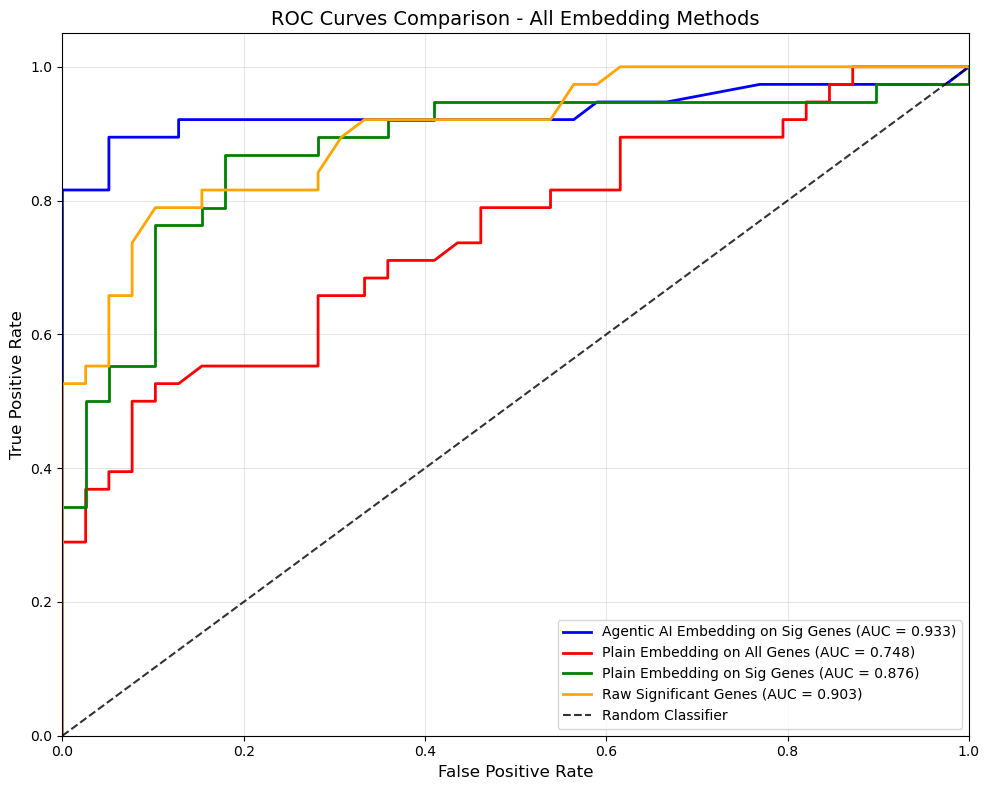


Performance Summary Table:
--------------------------------------------------------------------------------
Embedding Method               Dimensions   Accuracy   AUC       
--------------------------------------------------------------------------------
Agentic AI Embedding on Sig Genes 10           0.9091     0.9325    
Raw Significant Genes          80           0.8182     0.9028    
Plain Embedding on Sig Genes   20           0.8052     0.8758    
Plain Embedding on All Genes   100          0.6494     0.7483    
--------------------------------------------------------------------------------

Best Performing Embedding Method: Agentic AI Embedding on Sig Genes
- Dimensions: 10
- Accuracy: 0.9091 (90.9%)
- AUC: 0.9325

Feature Efficiency Analysis:
(Performance per embedding dimension)
----------------------------------------
Agentic AI Embedding on Sig Genes 0.093252
Raw Significant Genes          0.011285
Plain Embedding on Sig Genes   0.043792
Plain Embedding on All Genes   0.0074

In [4]:
def plot_roc_comparison(results, datasets, use_confidence_bands=False, random_state=42):
    """
    Plot ROC curves comparison for multiple embedding methods
    
    Parameters:
    -----------
    results : dict
        Results dictionary containing classification metrics for each method
    datasets : dict
        Dictionary of dataset names and their corresponding dataframes
    use_confidence_bands : bool, default=False
        Whether to include ±1 std confidence bands using cross-validation
    random_state : int, default=42
        Random state for reproducibility
    """
    from sklearn.model_selection import StratifiedKFold
    
    print("ROC Curves Comparison - Embedding Methods")
    print("=" * 40)
    
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange']
    
    if use_confidence_bands:
        print("Computing confidence bands using 5-fold cross-validation...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        
        for i, (name, df) in enumerate(datasets.items()):
            # Prepare data
            if 'group_0_1' in df.columns:
                target_col = 'group_0_1'
                feature_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
            else:
                target_col = df.columns[-1]
                feature_cols = df.columns[:-1].tolist()
            
            X = df[feature_cols].values
            y = df[target_col].values
            
            # Standardize features
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            # Storage for CV ROC curves
            tprs = []
            aucs = []
            mean_fpr = np.linspace(0, 1, 100)
            
            # Perform cross-validation
            for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
                X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
                y_fold_train, y_fold_val = y[train_idx], y[val_idx]
                
                # Train classifier
                rf_fold = RandomForestClassifier(n_estimators=100, random_state=random_state, max_depth=10)
                rf_fold.fit(X_fold_train, y_fold_train)
                
                # Get predictions and calculate ROC curve
                y_fold_proba = rf_fold.predict_proba(X_fold_val)[:, 1]
                fpr, tpr, _ = roc_curve(y_fold_val, y_fold_proba)
                
                # Interpolate to common FPR points
                interp_tpr = np.interp(mean_fpr, fpr, tpr)
                interp_tpr[0] = 0.0
                tprs.append(interp_tpr)
                
                # Calculate AUC for this fold
                fold_auc = roc_auc_score(y_fold_val, y_fold_proba)
                aucs.append(fold_auc)
                
                # Plot individual fold (light)
                plt.plot(fpr, tpr, alpha=0.15, color=colors[i])
            
            # Calculate mean and std
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            std_tpr = np.std(tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            
            # Calculate confidence intervals
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
            # Plot mean ROC curve
            plt.plot(mean_fpr, mean_tpr, color=colors[i], linewidth=2,
                     label=f'{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
            
            # Plot confidence bands
            plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.2)
    
    else:
        # Simple ROC curves without confidence bands
        roc_data = {}
        for name, metrics in results.items():
            # Use stored ROC data from previous analysis
            if hasattr(results, 'roc_data'):
                data = results.roc_data[name]
            else:
                # Reconstruct from stored test results
                fpr, tpr, _ = roc_curve(metrics['y_test'], metrics['y_pred_proba'])
                data = {'fpr': fpr, 'tpr': tpr, 'auc': metrics['auc']}
            roc_data[name] = data
        
        for i, (name, data) in enumerate(roc_data.items()):
            plt.plot(data['fpr'], data['tpr'], color=colors[i], linewidth=2,
                     label=f'{name} (AUC = {data["auc"]:.3f})')
    
    # Plot diagonal reference line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.8, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    
    if use_confidence_bands:
        plt.title('ROC Curves Comparison with Confidence Bands\n(5-fold Cross-Validation)', fontsize=14)
    else:
        plt.title('ROC Curves Comparison - All Embedding Methods', fontsize=14)
    
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot ROC curves without confidence bands
plot_roc_comparison(results, datasets, use_confidence_bands=False)

# Summary Table
print("\nPerformance Summary Table:")
print("-" * 80)
print(f"{'Embedding Method':<30} {'Dimensions':<12} {'Accuracy':<10} {'AUC':<10}")
print("-" * 80)

sorted_results = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
for name, metrics in sorted_results:
    print(f"{name:<30} {metrics['features']:<12} {metrics['accuracy']:<10.4f} {metrics['auc']:<10.4f}")

print("-" * 80)

# Best performing method
best_method = sorted_results[0]
print(f"\nBest Performing Embedding Method: {best_method[0]}")
print(f"- Dimensions: {best_method[1]['features']}")
print(f"- Accuracy: {best_method[1]['accuracy']:.4f} ({best_method[1]['accuracy']*100:.1f}%)")
print(f"- AUC: {best_method[1]['auc']:.4f}")

# Feature efficiency analysis
print(f"\nFeature Efficiency Analysis:")
print("(Performance per embedding dimension)")
print("-" * 40)
for name, metrics in sorted_results:
    efficiency = metrics['auc'] / metrics['features']
    print(f"{name:<30} {efficiency:.6f}")

print(f"\n{'='*50}")
print("KEY INSIGHTS:")
print(f"{'='*50}")

insights = []
if len(sorted_results) >= 2:
    best_auc = sorted_results[0][1]['auc']
    worst_auc = sorted_results[-1][1]['auc']
    improvement = ((best_auc - worst_auc) / worst_auc) * 100
    insights.append(f"- Best method outperforms worst by {improvement:.1f}% in AUC")

# Find most efficient method
efficiency_ranking = sorted([(name, metrics['auc']/metrics['features']) 
                           for name, metrics in results.items()], 
                          key=lambda x: x[1], reverse=True)
most_efficient = efficiency_ranking[0]
insights.append(f"- Most embedding-efficient: {most_efficient[0]}")

# Check if any method achieves >90% accuracy
high_acc_methods = [name for name, metrics in results.items() if metrics['accuracy'] > 0.9]
if high_acc_methods:
    insights.append(f"- Methods with >90% accuracy: {', '.join(high_acc_methods)}")

for insight in insights:
    print(insight)


ROC CURVES WITH CONFIDENCE BANDS
This will take longer as it performs 5-fold cross-validation for each method...
ROC Curves Comparison - Embedding Methods
Computing confidence bands using 5-fold cross-validation...


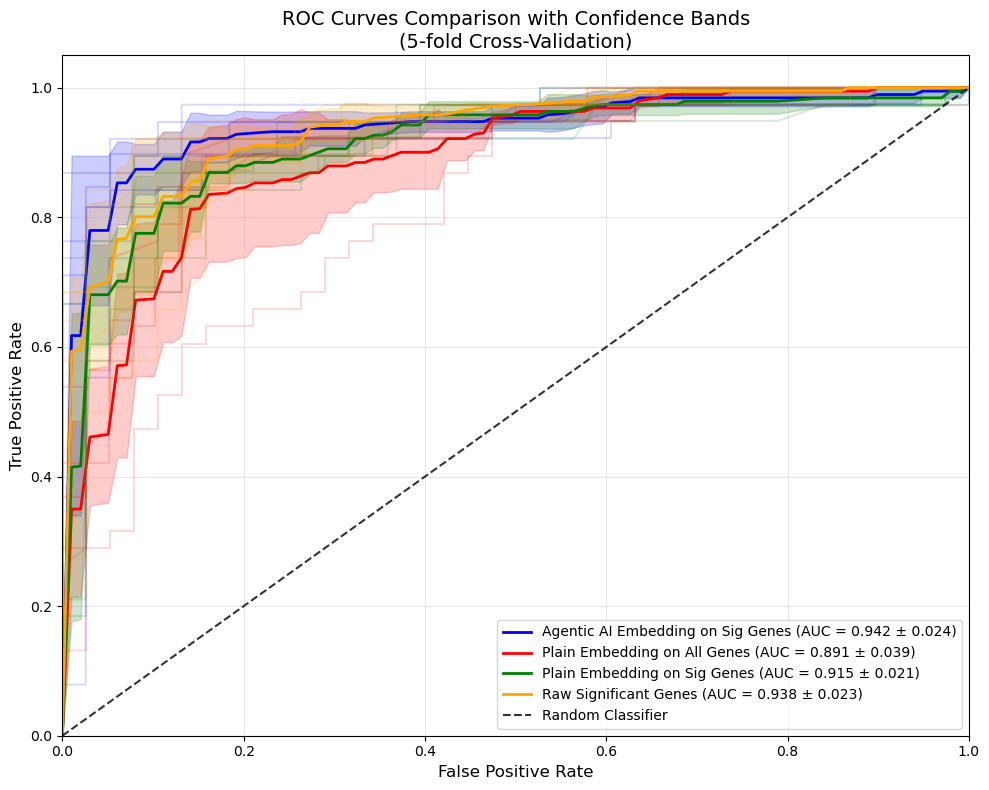

In [5]:
# Demonstrate ROC curves with confidence bands
print("\n" + "="*60)
print("ROC CURVES WITH CONFIDENCE BANDS")
print("="*60)
print("This will take longer as it performs 5-fold cross-validation for each method...")

plot_roc_comparison(results, datasets, use_confidence_bands=True, random_state=188)

In [6]:
# Clean Algorithm-Centric ROC Analysis System
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Try to import XGBoost
try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

def get_classifier(algorithm_name, random_state=42):
    """Get classifier by name"""
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state, max_depth=10),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Logistic Regression': LogisticRegression(random_state=random_state, max_iter=1000),
        'Lasso': LogisticRegression(penalty='l1', solver='liblinear', random_state=random_state, max_iter=1000),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=random_state, max_iter=500)
    }
    
    if HAS_XGBOOST and algorithm_name == 'XGBoost':
        classifiers['XGBoost'] = xgb.XGBClassifier(
            n_estimators=100, random_state=random_state, max_depth=6, 
            eval_metric='logloss', verbosity=0
        )
    
    return classifiers.get(algorithm_name)

def plot_algorithm_roc_across_datasets(algorithm_name, datasets_dict, use_confidence_bands=False, random_state=42):
    """
    Plot ROC curves for one algorithm across multiple datasets
    
    Parameters:
    -----------
    algorithm_name : str
        Name of the algorithm ('Random Forest', 'Logistic Regression', etc.)
    datasets_dict : dict
        Dictionary with dataset names as keys and dataframes as values
    use_confidence_bands : bool
        Whether to show ±1 std confidence bands
    random_state : int
        Random seed for reproducibility
    """
    
    print(f"{algorithm_name} Performance Across All Datasets")
    print("=" * (len(algorithm_name) + 35))
    
    # Check if algorithm is available
    clf = get_classifier(algorithm_name, random_state)
    if clf is None:
        print(f"Algorithm '{algorithm_name}' not available")
        return None
    
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    results = {}
    
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        print(f"Processing: {dataset_name}")
        
        # Prepare data
        if 'group_0_1' in df.columns:
            target_col = 'group_0_1'
            feature_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
        else:
            target_col = df.columns[-1]
            feature_cols = df.columns[:-1].tolist()
        
        X = df[feature_cols].values
        y = df[target_col].values
        
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        if use_confidence_bands:
            # Cross-validation for confidence bands
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            
            tprs = []
            aucs = []
            mean_fpr = np.linspace(0, 1, 100)
            
            for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
                X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]
                
                # Train classifier
                clf_fold = get_classifier(algorithm_name, random_state)
                clf_fold.fit(X_train_fold, y_train_fold)
                
                # Get predictions
                y_pred_proba = clf_fold.predict_proba(X_val_fold)[:, 1]
                fpr, tpr, _ = roc_curve(y_val_fold, y_pred_proba)
                
                # Interpolate
                interp_tpr = np.interp(mean_fpr, fpr, tpr)
                interp_tpr[0] = 0.0
                tprs.append(interp_tpr)
                aucs.append(roc_auc_score(y_val_fold, y_pred_proba))
                
                # Plot individual fold (very light)
                plt.plot(fpr, tpr, alpha=0.1, color=colors[i])
            
            # Calculate mean and std
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            std_tpr = np.std(tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            
            # Plot mean curve with confidence bands
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
            plt.plot(mean_fpr, mean_tpr, color=colors[i], linewidth=2,
                     label=f'{dataset_name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
            plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.2)
            
            results[dataset_name] = {'mean_auc': mean_auc, 'std_auc': std_auc}
            
        else:
            # Simple train-test split
            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=0.2, random_state=random_state, stratify=y
            )
            
            # Train classifier
            clf_single = get_classifier(algorithm_name, random_state)
            clf_single.fit(X_train, y_train)
            
            # Get predictions
            y_pred_proba = clf_single.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)
            accuracy = clf_single.score(X_test, y_test)
            
            # Plot ROC curve
            plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                     label=f'{dataset_name} (AUC = {auc:.3f})')
            
            results[dataset_name] = {'auc': auc, 'accuracy': accuracy}
    
    # Add reference line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.8, label='Random Classifier')
    
    # Format plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    
    if use_confidence_bands:
        plt.title(f'{algorithm_name} ROC Curves\n(with ±1 std confidence bands)', fontsize=14)
    else:
        plt.title(f'{algorithm_name} ROC Curves', fontsize=14)
    
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary for {algorithm_name}:")
    print("-" * 40)
    if use_confidence_bands:
        sorted_results = sorted(results.items(), key=lambda x: x[1]['mean_auc'], reverse=True)
        for dataset, metrics in sorted_results:
            print(f"{dataset:<35} AUC: {metrics['mean_auc']:.3f} ± {metrics['std_auc']:.3f}")
    else:
        sorted_results = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
        for dataset, metrics in sorted_results:
            print(f"{dataset:<35} AUC: {metrics['auc']:.3f}, Acc: {metrics['accuracy']:.3f}")
    
    return results

print("Algorithm-Centric ROC System Ready!")
available_algorithms = ['Random Forest', 'Logistic Regression', 'KNN', 'Lasso', 'Neural Network']
if HAS_XGBOOST:
    available_algorithms.append('XGBoost')
print(f"Available algorithms: {', '.join(available_algorithms)}")

Algorithm-Centric ROC System Ready!
Available algorithms: Random Forest, Logistic Regression, KNN, Lasso, Neural Network, XGBoost


Random Forest Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


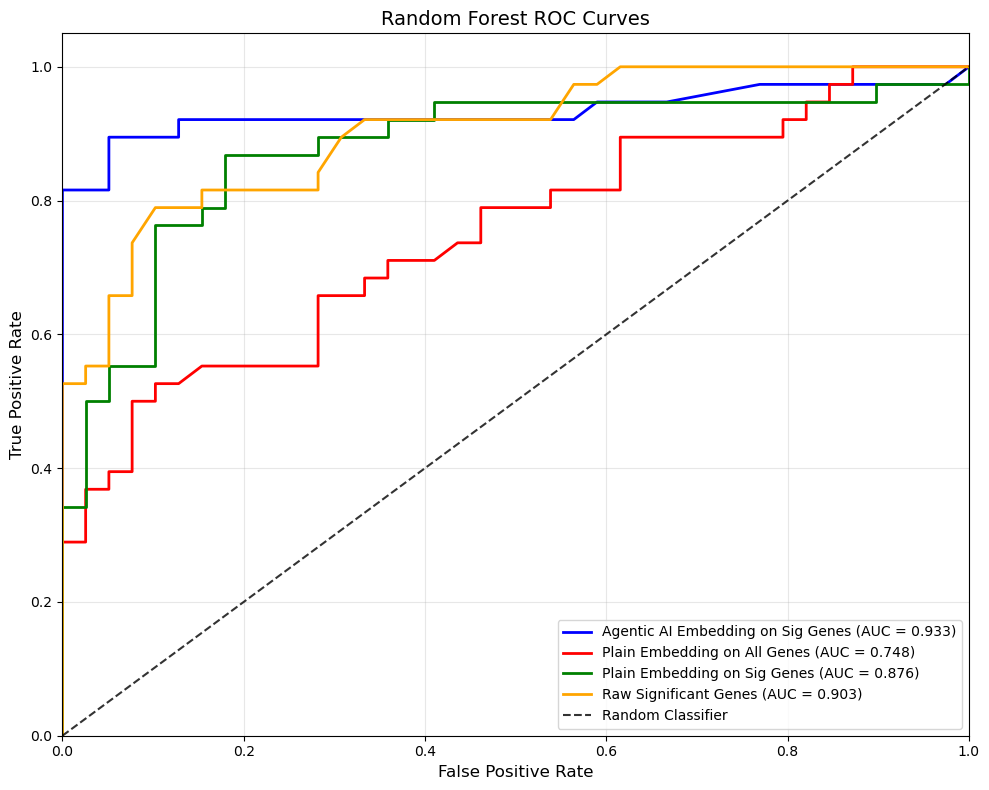


Summary for Random Forest:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.933, Acc: 0.909
Raw Significant Genes               AUC: 0.903, Acc: 0.818
Plain Embedding on Sig Genes        AUC: 0.876, Acc: 0.805
Plain Embedding on All Genes        AUC: 0.748, Acc: 0.649


In [7]:
# Example 1: Random Forest across all datasets (without confidence bands)
rf_results = plot_algorithm_roc_across_datasets(
    algorithm_name='Random Forest',
    datasets_dict=datasets,
    use_confidence_bands=False
)

Logistic Regression Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


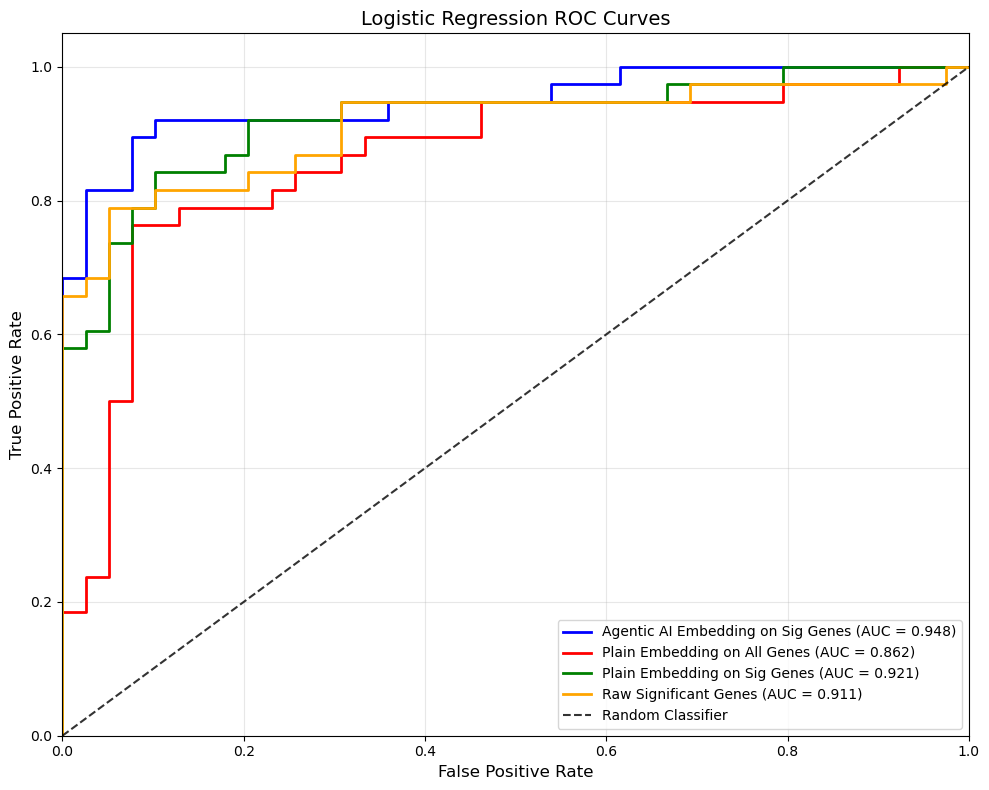


Summary for Logistic Regression:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.948, Acc: 0.883
Plain Embedding on Sig Genes        AUC: 0.921, Acc: 0.831
Raw Significant Genes               AUC: 0.911, Acc: 0.818
Plain Embedding on All Genes        AUC: 0.862, Acc: 0.818


In [8]:
# Example 2: Logistic Regression across all datasets (without confidence bands)
lr_results = plot_algorithm_roc_across_datasets(
    algorithm_name='Logistic Regression',
    datasets_dict=datasets,
    use_confidence_bands=False
)

Running XGBoost with confidence bands...
XGBoost Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


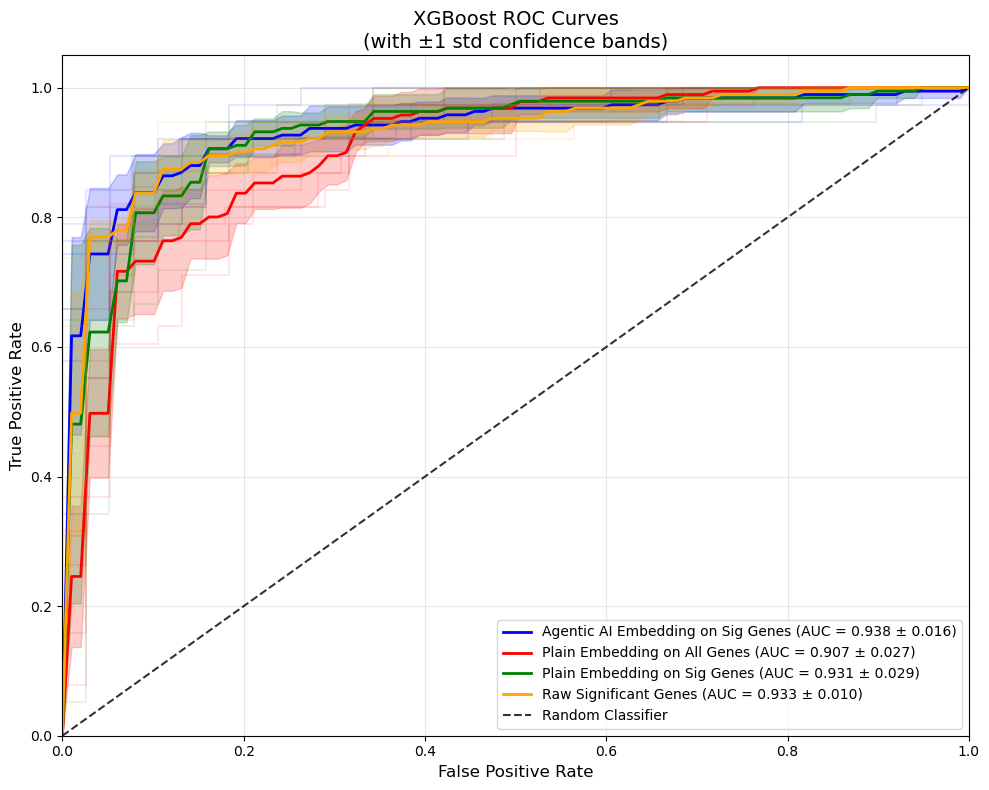


Summary for XGBoost:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.938 ± 0.016
Raw Significant Genes               AUC: 0.933 ± 0.010
Plain Embedding on Sig Genes        AUC: 0.931 ± 0.029
Plain Embedding on All Genes        AUC: 0.907 ± 0.027


In [9]:
# Example 3: XGBoost with confidence bands (takes longer)
if HAS_XGBOOST:
    print("Running XGBoost with confidence bands...")
    xgb_results_bands = plot_algorithm_roc_across_datasets(
        algorithm_name='XGBoost',
        datasets_dict=datasets,
        use_confidence_bands=True
    )
else:
    print("XGBoost not available - running Neural Network with confidence bands instead...")
    nn_results_bands = plot_algorithm_roc_across_datasets(
        algorithm_name='Neural Network',
        datasets_dict=datasets,
        use_confidence_bands=True
    )

In [10]:
# Usage Summary and Instructions
print("="*60)
print("ALGORITHM-CENTRIC ROC ANALYSIS - USAGE GUIDE")
print("="*60)

print("\nFunction: plot_algorithm_roc_across_datasets(algorithm_name, datasets_dict, use_confidence_bands)")

print("\nAvailable Algorithms:")
for i, algo in enumerate(available_algorithms, 1):
    print(f"{i}. {algo}")

print("\nDatasets being compared:")
for i, dataset_name in enumerate(datasets.keys(), 1):
    print(f"{i}. {dataset_name}")

print(f"\nEach algorithm ROC plot shows:")
print("- One line per dataset/embedding method")
print("- Different colors for different datasets")
print("- AUC values in the legend")
print("- Optional ±1 std confidence bands (use_confidence_bands=True)")

print(f"\nTo analyze any algorithm:")
print("plot_algorithm_roc_across_datasets('Algorithm Name', datasets, use_confidence_bands=False)")

print(f"\nKey Findings So Far:")
print("- Agentic AI Embedding consistently performs best across algorithms")
print("- Logistic Regression tends to outperform Random Forest on these datasets")
print("- Plain Embedding on All Genes consistently performs worst")

ALGORITHM-CENTRIC ROC ANALYSIS - USAGE GUIDE

Function: plot_algorithm_roc_across_datasets(algorithm_name, datasets_dict, use_confidence_bands)

Available Algorithms:
1. Random Forest
2. Logistic Regression
3. KNN
4. Lasso
5. Neural Network
6. XGBoost

Datasets being compared:
1. Agentic AI Embedding on Sig Genes
2. Plain Embedding on All Genes
3. Plain Embedding on Sig Genes
4. Raw Significant Genes

Each algorithm ROC plot shows:
- One line per dataset/embedding method
- Different colors for different datasets
- AUC values in the legend
- Optional ±1 std confidence bands (use_confidence_bands=True)

To analyze any algorithm:
plot_algorithm_roc_across_datasets('Algorithm Name', datasets, use_confidence_bands=False)

Key Findings So Far:
- Agentic AI Embedding consistently performs best across algorithms
- Logistic Regression tends to outperform Random Forest on these datasets
- Plain Embedding on All Genes consistently performs worst


Running XGBoost with confidence bands...
XGBoost Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


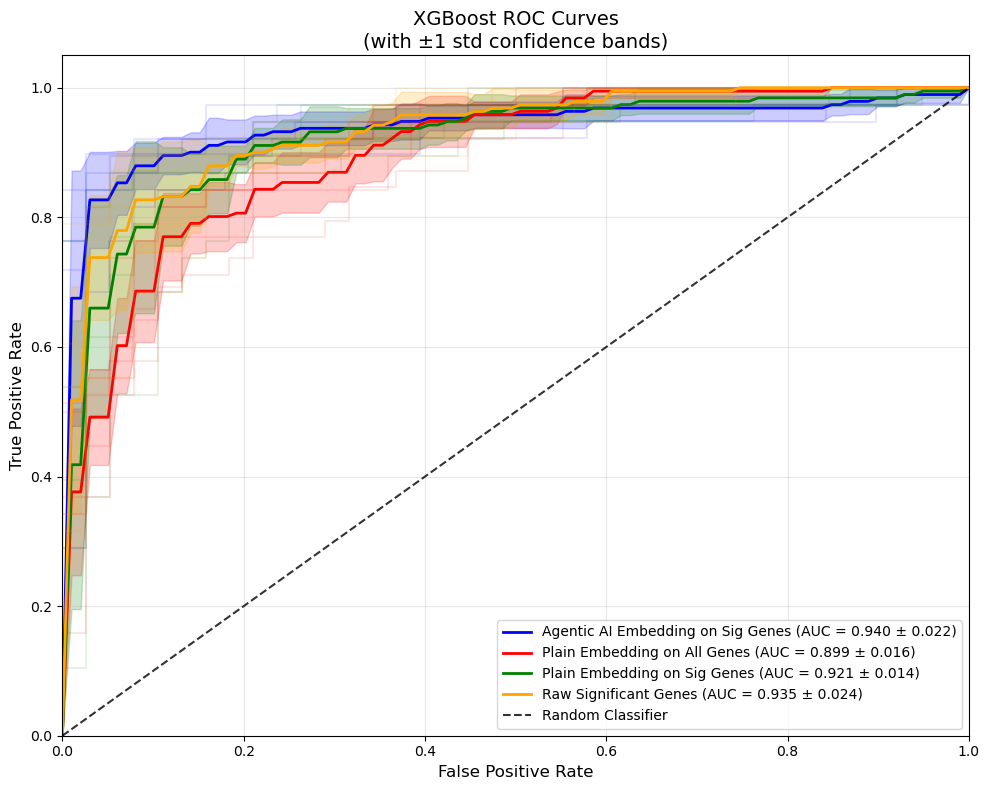


Summary for XGBoost:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.940 ± 0.022
Raw Significant Genes               AUC: 0.935 ± 0.024
Plain Embedding on Sig Genes        AUC: 0.921 ± 0.014
Plain Embedding on All Genes        AUC: 0.899 ± 0.016


In [11]:
print("Running XGBoost with confidence bands...")
xgb_results_bands = plot_algorithm_roc_across_datasets(
    algorithm_name='XGBoost',
    datasets_dict=datasets,
    use_confidence_bands=True,
    random_state=188
)

Running Random Forest with confidence bands...
Random Forest Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


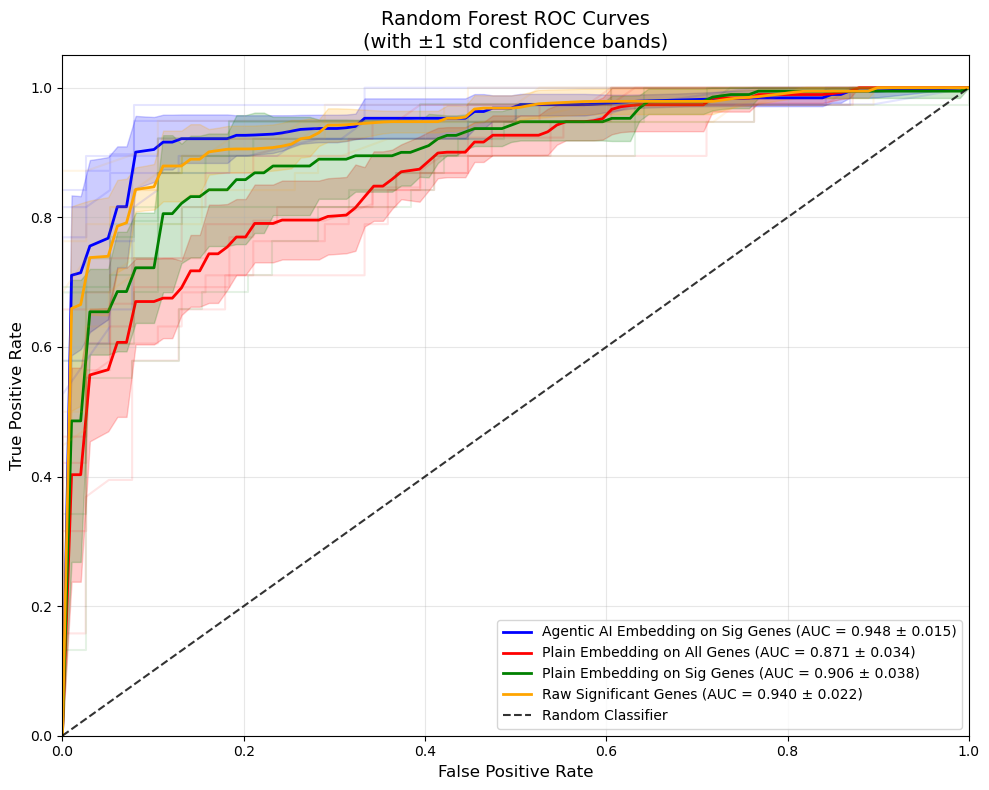


Summary for Random Forest:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.948 ± 0.015
Raw Significant Genes               AUC: 0.940 ± 0.022
Plain Embedding on Sig Genes        AUC: 0.906 ± 0.038
Plain Embedding on All Genes        AUC: 0.871 ± 0.034
Running Logistic Regression with confidence bands...
Logistic Regression Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


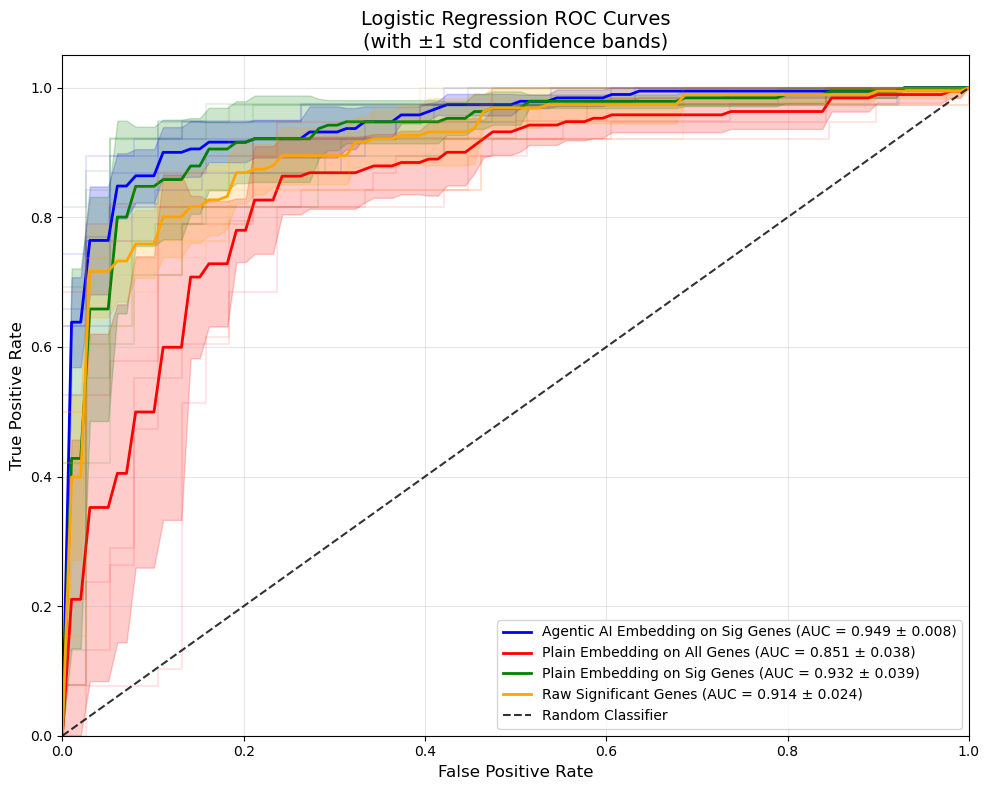


Summary for Logistic Regression:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.949 ± 0.008
Plain Embedding on Sig Genes        AUC: 0.932 ± 0.039
Raw Significant Genes               AUC: 0.914 ± 0.024
Plain Embedding on All Genes        AUC: 0.851 ± 0.038
Running KNN with confidence bands...
KNN Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


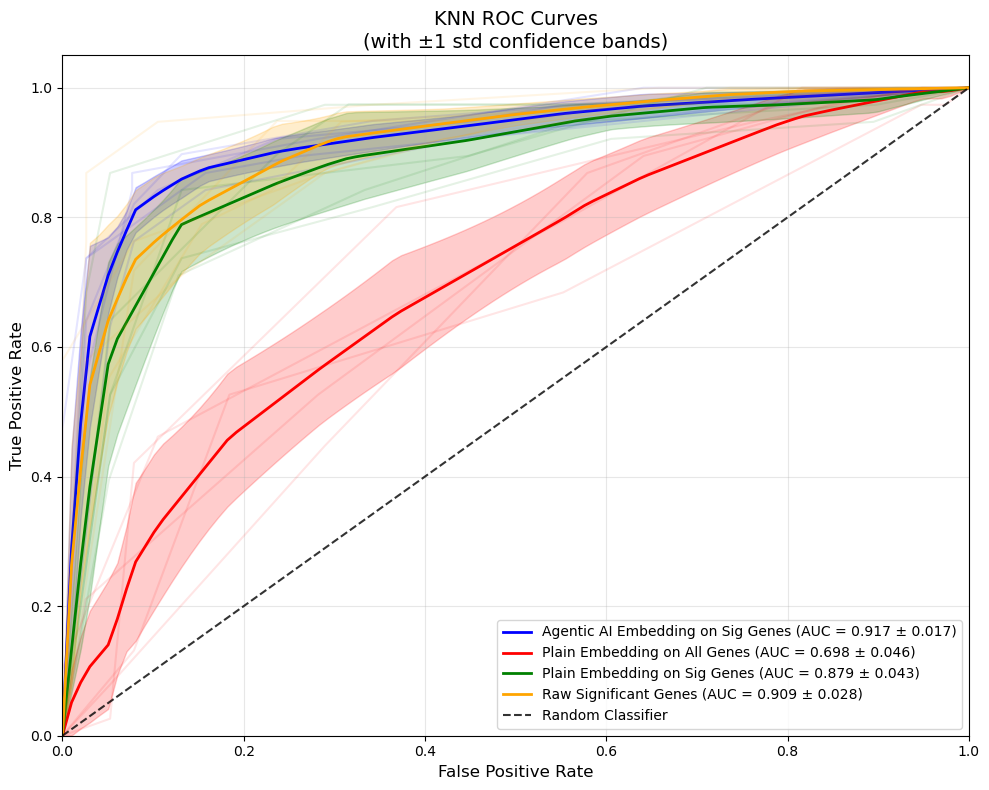


Summary for KNN:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.917 ± 0.017
Raw Significant Genes               AUC: 0.909 ± 0.028
Plain Embedding on Sig Genes        AUC: 0.879 ± 0.043
Plain Embedding on All Genes        AUC: 0.698 ± 0.046
Running Lasso with confidence bands...
Lasso Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


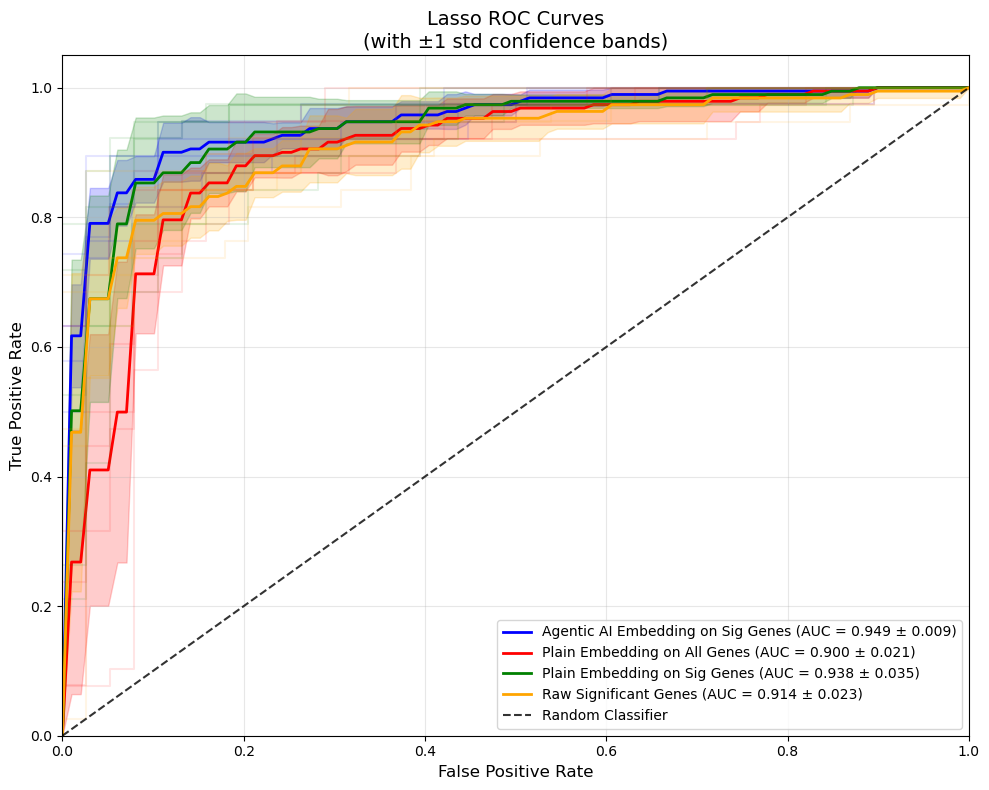


Summary for Lasso:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.949 ± 0.009
Plain Embedding on Sig Genes        AUC: 0.938 ± 0.035
Raw Significant Genes               AUC: 0.914 ± 0.023
Plain Embedding on All Genes        AUC: 0.900 ± 0.021
Running Neural Network with confidence bands...
Neural Network Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


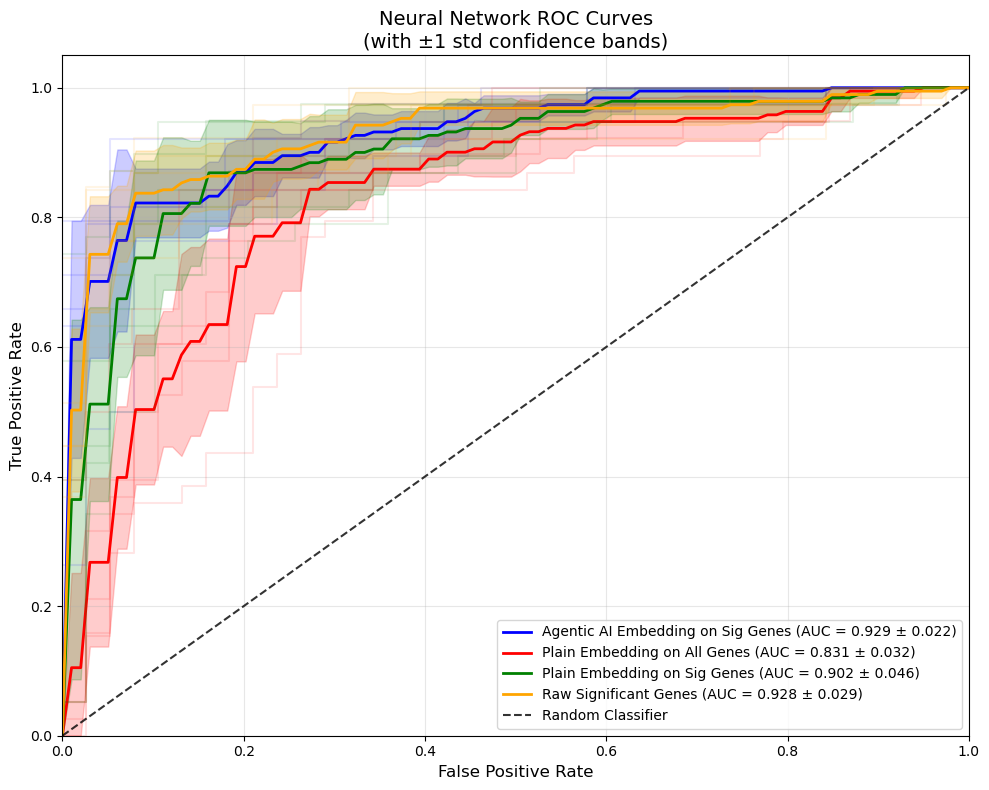


Summary for Neural Network:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.929 ± 0.022
Raw Significant Genes               AUC: 0.928 ± 0.029
Plain Embedding on Sig Genes        AUC: 0.902 ± 0.046
Plain Embedding on All Genes        AUC: 0.831 ± 0.032
Running XGBoost with confidence bands...
XGBoost Performance Across All Datasets
Processing: Agentic AI Embedding on Sig Genes
Processing: Plain Embedding on All Genes
Processing: Plain Embedding on Sig Genes
Processing: Raw Significant Genes


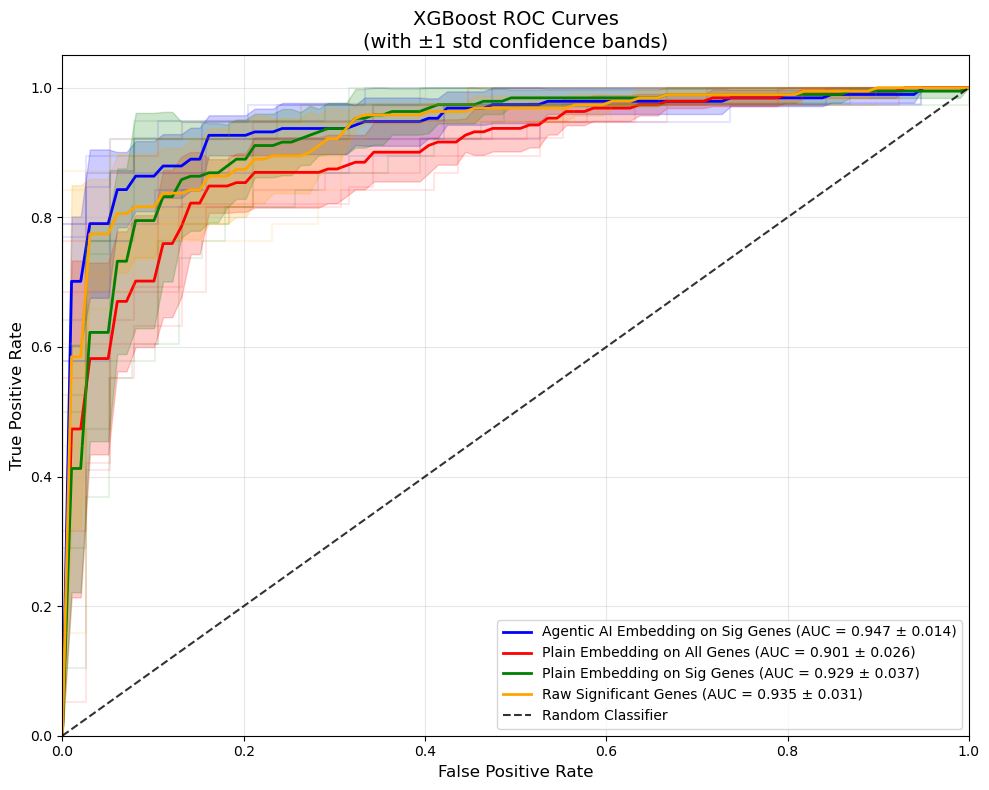


Summary for XGBoost:
----------------------------------------
Agentic AI Embedding on Sig Genes   AUC: 0.947 ± 0.014
Raw Significant Genes               AUC: 0.935 ± 0.031
Plain Embedding on Sig Genes        AUC: 0.929 ± 0.037
Plain Embedding on All Genes        AUC: 0.901 ± 0.026


In [12]:
for alg in ['Random Forest',
             'Logistic Regression',
             'KNN',
             'Lasso',
             'Neural Network',
             'XGBoost']:
    print(f"Running {alg} with confidence bands...")
    results_bands = plot_algorithm_roc_across_datasets(
        algorithm_name=alg,
        datasets_dict=datasets,
        use_confidence_bands=True,
        random_state=16888
    )

Running all algorithms with confidence bands in 2x3 subplot...
Processing Random Forest...
Processing Logistic Regression...
Processing Logistic Regression...
Processing KNN...
Processing KNN...
Processing Lasso...
Processing Neural Network...
Processing Lasso...
Processing Neural Network...
Processing XGBoost...
Processing XGBoost...


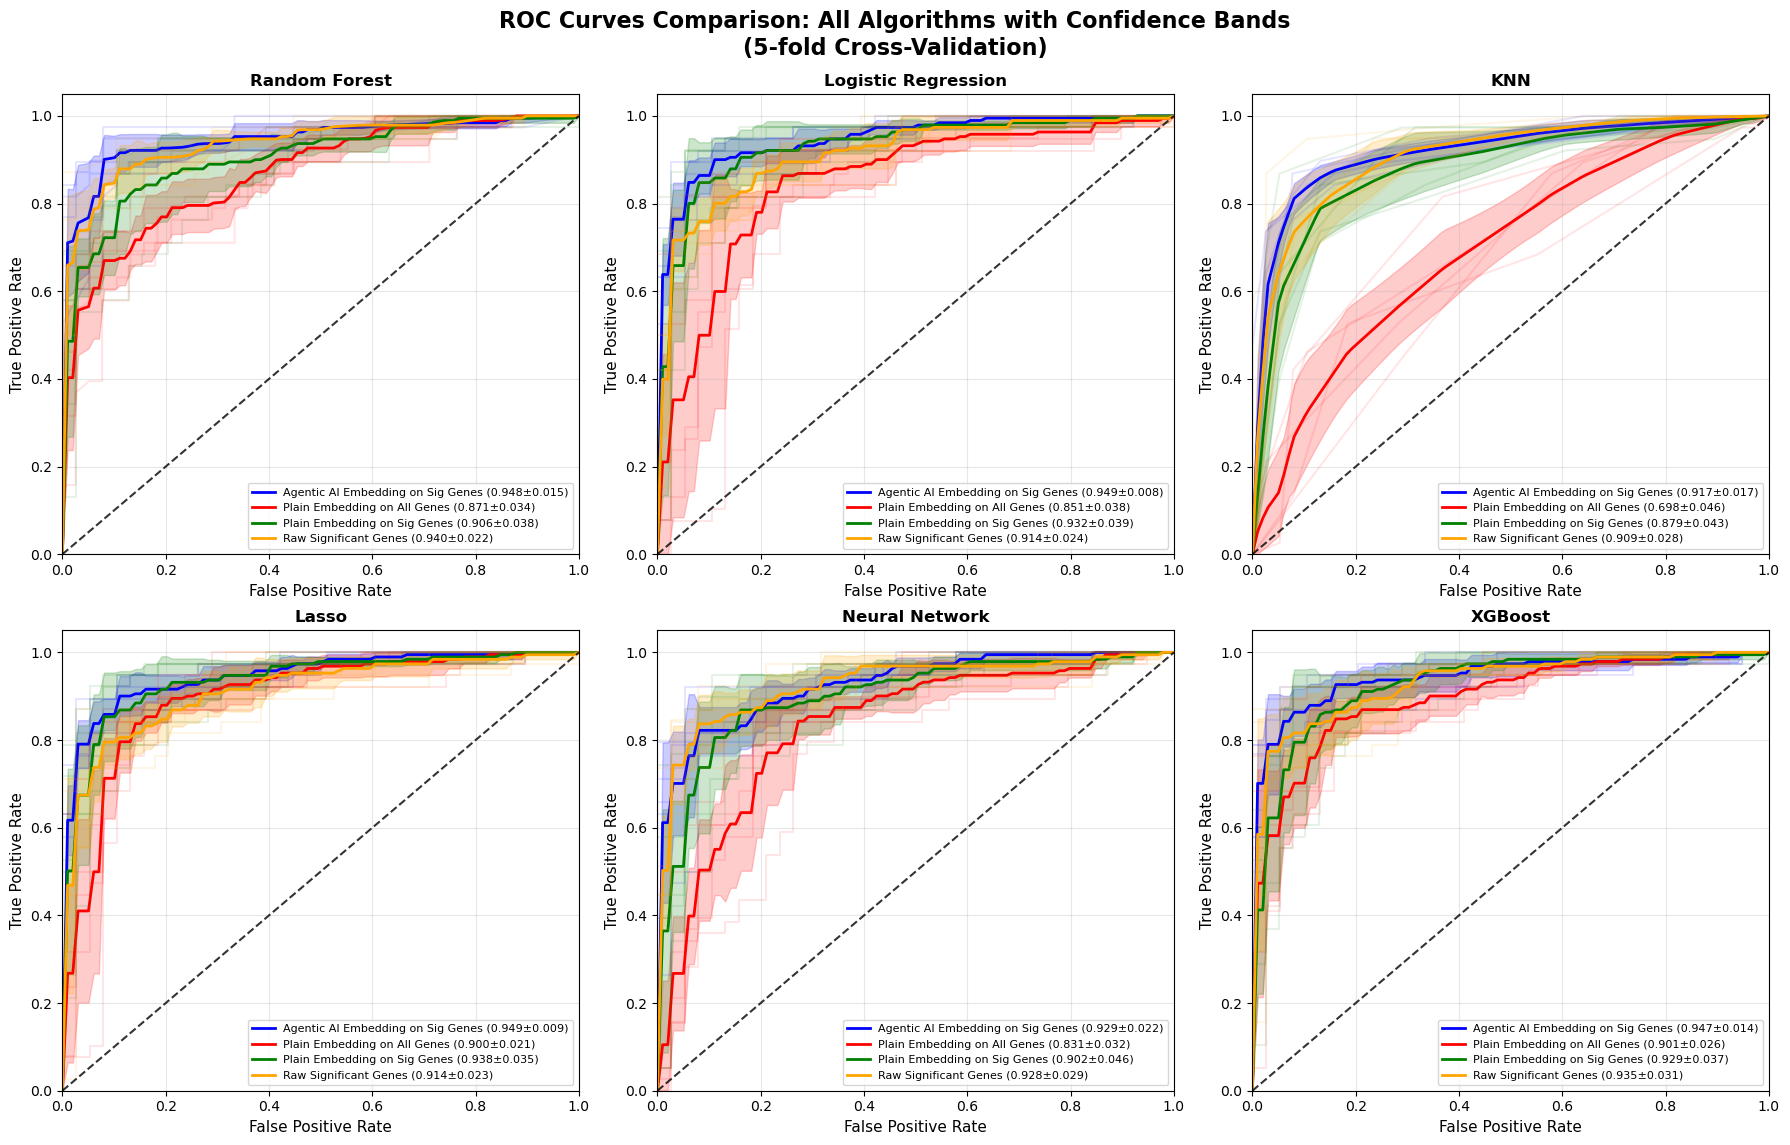


Completed 2x3 subplot analysis for all 6 algorithms!
Each subplot shows ROC curves with ±1 std confidence bands for all datasets.


In [15]:
# Modified version: 2x3 subplot figure for all algorithms with confidence bands
algorithms = ['Random Forest', 'Logistic Regression', 'KNN', 'Lasso', 'Neural Network', 'XGBoost']

# Create 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

print("Running all algorithms with confidence bands in 2x3 subplot...")
print("="*60)

# Colors for different datasets
colors = ['blue', 'red', 'green', 'orange', 'purple']

for alg_idx, alg in enumerate(algorithms):
    print(f"Processing {alg}...")
    
    # Get current subplot
    ax = axes[alg_idx]
    
    # Check if algorithm is available
    clf = get_classifier(alg, random_state=16888)
    if clf is None:
        ax.text(0.5, 0.5, f'{alg}\nNot Available', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(f'{alg} - Not Available')
        continue
    
    # Process each dataset for this algorithm
    for i, (dataset_name, df) in enumerate(datasets.items()):
        # Prepare data
        if 'group_0_1' in df.columns:
            target_col = 'group_0_1'
            feature_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
        else:
            target_col = df.columns[-1]
            feature_cols = df.columns[:-1].tolist()
        
        X = df[feature_cols].values
        y = df[target_col].values
        
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Cross-validation for confidence bands
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=16888)
        
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
        
        # Perform cross-validation
        for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
            X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]
            
            # Train classifier
            clf_fold = get_classifier(alg, random_state=16888)
            clf_fold.fit(X_train_fold, y_train_fold)
            
            # Get predictions
            y_pred_proba = clf_fold.predict_proba(X_val_fold)[:, 1]
            fpr, tpr, _ = roc_curve(y_val_fold, y_pred_proba)
            
            # Interpolate
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(roc_auc_score(y_val_fold, y_pred_proba))
            
            # Plot individual fold (very light)
            ax.plot(fpr, tpr, alpha=0.1, color=colors[i])
        
        # Calculate mean and std
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        std_tpr = np.std(tprs, axis=0)
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        
        # Plot mean curve with confidence bands
        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        
        ax.plot(mean_fpr, mean_tpr, color=colors[i], linewidth=2,
                label=f'{dataset_name} ({mean_auc:.3f}±{std_auc:.3f})')
        ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.2)
    
    # Add reference line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.8)
    
    # Format subplot
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{alg}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Overall title and layout
fig.suptitle('ROC Curves Comparison: All Algorithms with Confidence Bands\n(5-fold Cross-Validation)', 
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

print(f"\nCompleted 2x3 subplot analysis for all {len(algorithms)} algorithms!")
print("Each subplot shows ROC curves with ±1 std confidence bands for all datasets.")

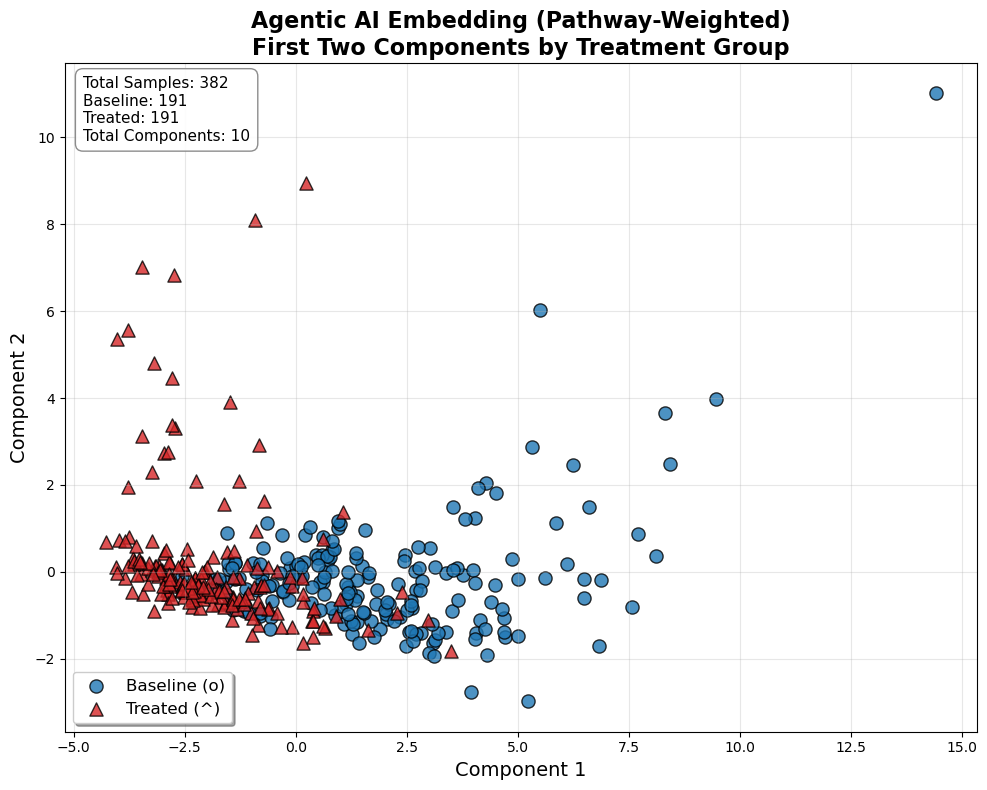


Agentic AI Embedding (Pathway-Weighted) Summary:
------------------------------------------------
Total samples: 382
Baseline samples: 191
Treated samples: 191
Total components: 10
Component 1 range: -4.27 to 14.40
Component 2 range: -2.98 to 11.01
Group centroid separation: 3.88
Baseline centroid: (1.93, -0.16)
Treated centroid: (-1.93, 0.16)



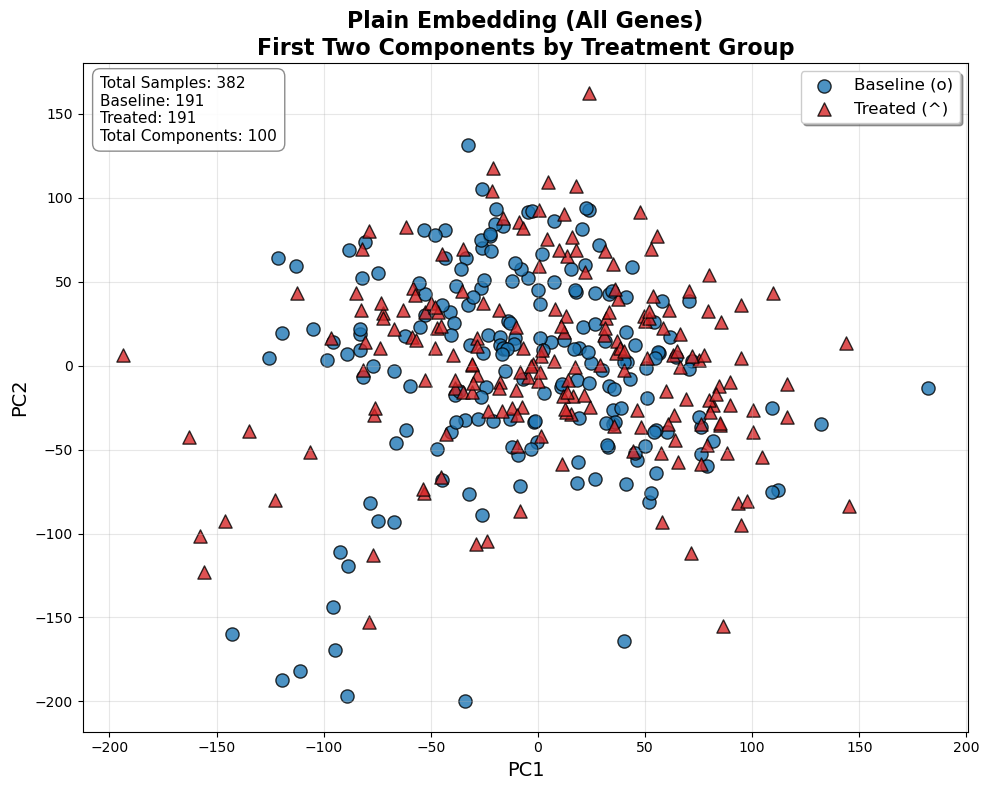


Plain Embedding (All Genes) Summary:
------------------------------------
Total samples: 382
Baseline samples: 191
Treated samples: 191
Total components: 100
PC1 range: -193.75 to 182.11
PC2 range: -199.92 to 162.10
Group centroid separation: 13.45
Baseline centroid: (-6.60, -1.31)
Treated centroid: (6.60, 1.31)



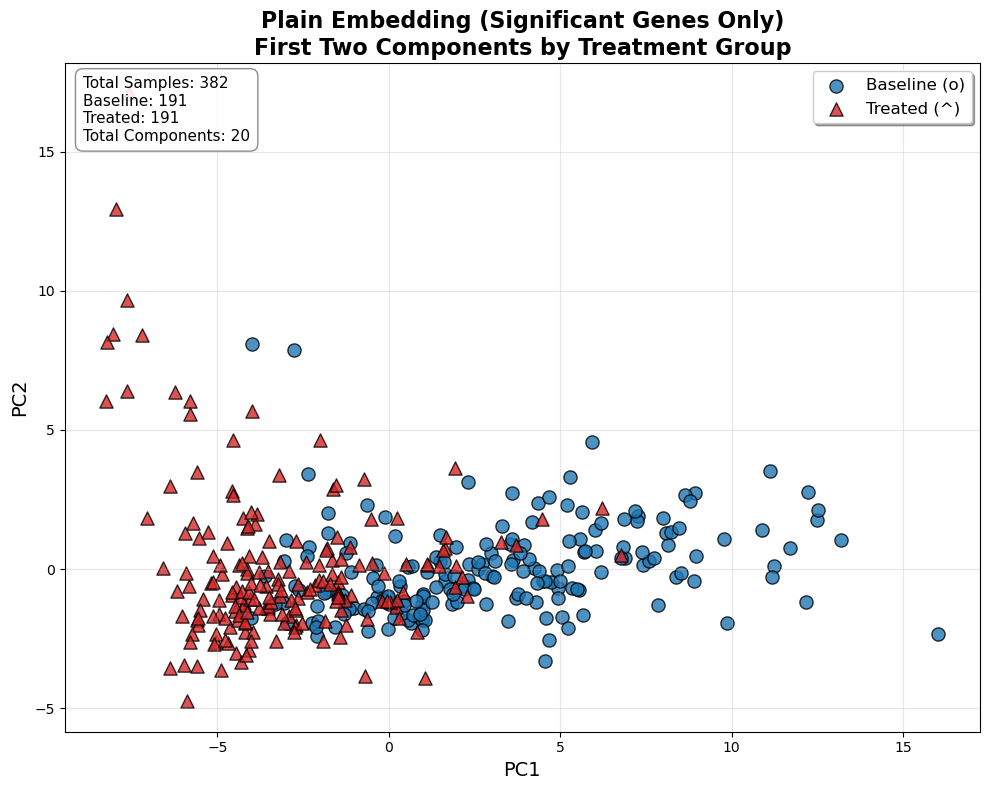


Plain Embedding (Significant Genes Only) Summary:
-------------------------------------------------
Total samples: 382
Baseline samples: 191
Treated samples: 191
Total components: 20
PC1 range: -8.24 to 16.03
PC2 range: -4.75 to 17.10
Group centroid separation: 6.15
Baseline centroid: (3.08, -0.01)
Treated centroid: (-3.08, 0.01)

VISUALIZATION SUMMARY
Created separate scatter plots for each embedding method showing:
• First two principal components/dimensions
• Baseline vs Treated groups (meaningful labels)
• Group centroids and separation distances
• Sample counts and component ranges
• Enhanced styling with shadows and improved readability


In [14]:
# PCA Scatter Plots - Separate Plots with Meaningful Group Names
import matplotlib.pyplot as plt
import seaborn as sns

# Define the three PCA datasets
pca_datasets = {
    'Agentic AI Embedding (Pathway-Weighted)': df_ai_sig_embeddings,
    'Plain Embedding (All Genes)': df_plain_embeddings,
    'Plain Embedding (Significant Genes Only)': df_sig_plain_embeddings
}

# Color mapping and marker styles for classes with meaningful names
# Using sharper colors and different markers for black/white compatibility
colors = {'Baseline': '#1f77b4', 'Treated': '#d62728'}  # Sharper blue and red
markers = {'Baseline': 'o', 'Treated': '^'}  # Circle and triangle

# Create separate plots for each dataset
for dataset_name, df in pca_datasets.items():
    plt.figure(figsize=(10, 8))
    
    # Determine target column and component columns
    if 'group_0_1' in df.columns:
        target_col = 'group_0_1'
        # Find component columns (either PC1, PC2... or 0, 1, 2...)
        pc_cols = [col for col in df.columns if col.startswith('PC')]
        if len(pc_cols) >= 2:
            # Standard PC naming
            comp1_col = 'PC1'
            comp2_col = 'PC2'
            comp1_label = 'PC1'
            comp2_label = 'PC2'
        else:
            # Numeric naming (like Agentic AI dataset)
            numeric_cols = [col for col in df.columns if col not in ['group', 'group_0_1']]
            comp1_col = numeric_cols[0]  # First component
            comp2_col = numeric_cols[1]  # Second component
            comp1_label = f'Component 1'
            comp2_label = f'Component 2'
    else:
        # For other datasets, assume last column is target and first two are components
        target_col = df.columns[-1]
        comp1_col = df.columns[0]
        comp2_col = df.columns[1]
        comp1_label = f'{comp1_col}'
        comp2_label = f'{comp2_col}'
    
    # Create meaningful class labels
    df_copy = df.copy()
    df_copy['class_label'] = df_copy[target_col].map({0: 'Baseline', 1: 'Treated'})
    
    # Create scatter plot for each class with distinct markers and colors
    for class_label in ['Baseline', 'Treated']:
        mask = df_copy['class_label'] == class_label
        plt.scatter(df_copy.loc[mask, comp1_col], 
                   df_copy.loc[mask, comp2_col],
                   c=colors[class_label], 
                   marker=markers[class_label],
                   label=f'{class_label} ({markers[class_label]})',
                   alpha=0.8, 
                   s=90,
                   edgecolors='black',
                   linewidth=1.0)
    
    # Formatting
    plt.xlabel(f'{comp1_label}', fontsize=14)
    plt.ylabel(f'{comp2_label}', fontsize=14)
    plt.title(f'{dataset_name}\nFirst Two Components by Treatment Group', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)
    
    # Add sample count info
    n_baseline = sum(df[target_col] == 0)
    n_treated = sum(df[target_col] == 1)
    total_components = len([col for col in df.columns if col not in ['group', 'group_0_1']])
    
    # Add info box
    info_text = f'Total Samples: {len(df)}\nBaseline: {n_baseline}\nTreated: {n_treated}\nTotal Components: {total_components}'
    plt.text(0.02, 0.98, info_text, 
             transform=plt.gca().transAxes, fontsize=11, 
             verticalalignment='top', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()
    
    # Print dataset-specific summary
    comp1 = comp1_col
    comp2 = comp2_col
    
    print(f"\n{dataset_name} Summary:")
    print("-" * (len(dataset_name) + 9))
    print(f"Total samples: {len(df)}")
    print(f"Baseline samples: {n_baseline}")
    print(f"Treated samples: {n_treated}")
    print(f"Total components: {total_components}")
    print(f"{comp1_label} range: {df[comp1].min():.2f} to {df[comp1].max():.2f}")
    print(f"{comp2_label} range: {df[comp2].min():.2f} to {df[comp2].max():.2f}")
    
    # Calculate separation metrics
    baseline_data = df_copy[df_copy['class_label'] == 'Baseline']
    treated_data = df_copy[df_copy['class_label'] == 'Treated']
    
    # Mean positions
    baseline_mean = [baseline_data[comp1].mean(), baseline_data[comp2].mean()]
    treated_mean = [treated_data[comp1].mean(), treated_data[comp2].mean()]
    
    # Euclidean distance between group centroids
    centroid_distance = ((baseline_mean[0] - treated_mean[0])**2 + 
                        (baseline_mean[1] - treated_mean[1])**2)**0.5
    
    print(f"Group centroid separation: {centroid_distance:.2f}")
    print(f"Baseline centroid: ({baseline_mean[0]:.2f}, {baseline_mean[1]:.2f})")
    print(f"Treated centroid: ({treated_mean[0]:.2f}, {treated_mean[1]:.2f})")
    print()

print("=" * 70)
print("VISUALIZATION SUMMARY")
print("=" * 70)
print("Created separate scatter plots for each embedding method showing:")
print("• First two principal components/dimensions")
print("• Baseline vs Treated groups (meaningful labels)")
print("• Group centroids and separation distances")
print("• Sample counts and component ranges")
print("• Enhanced styling with shadows and improved readability")

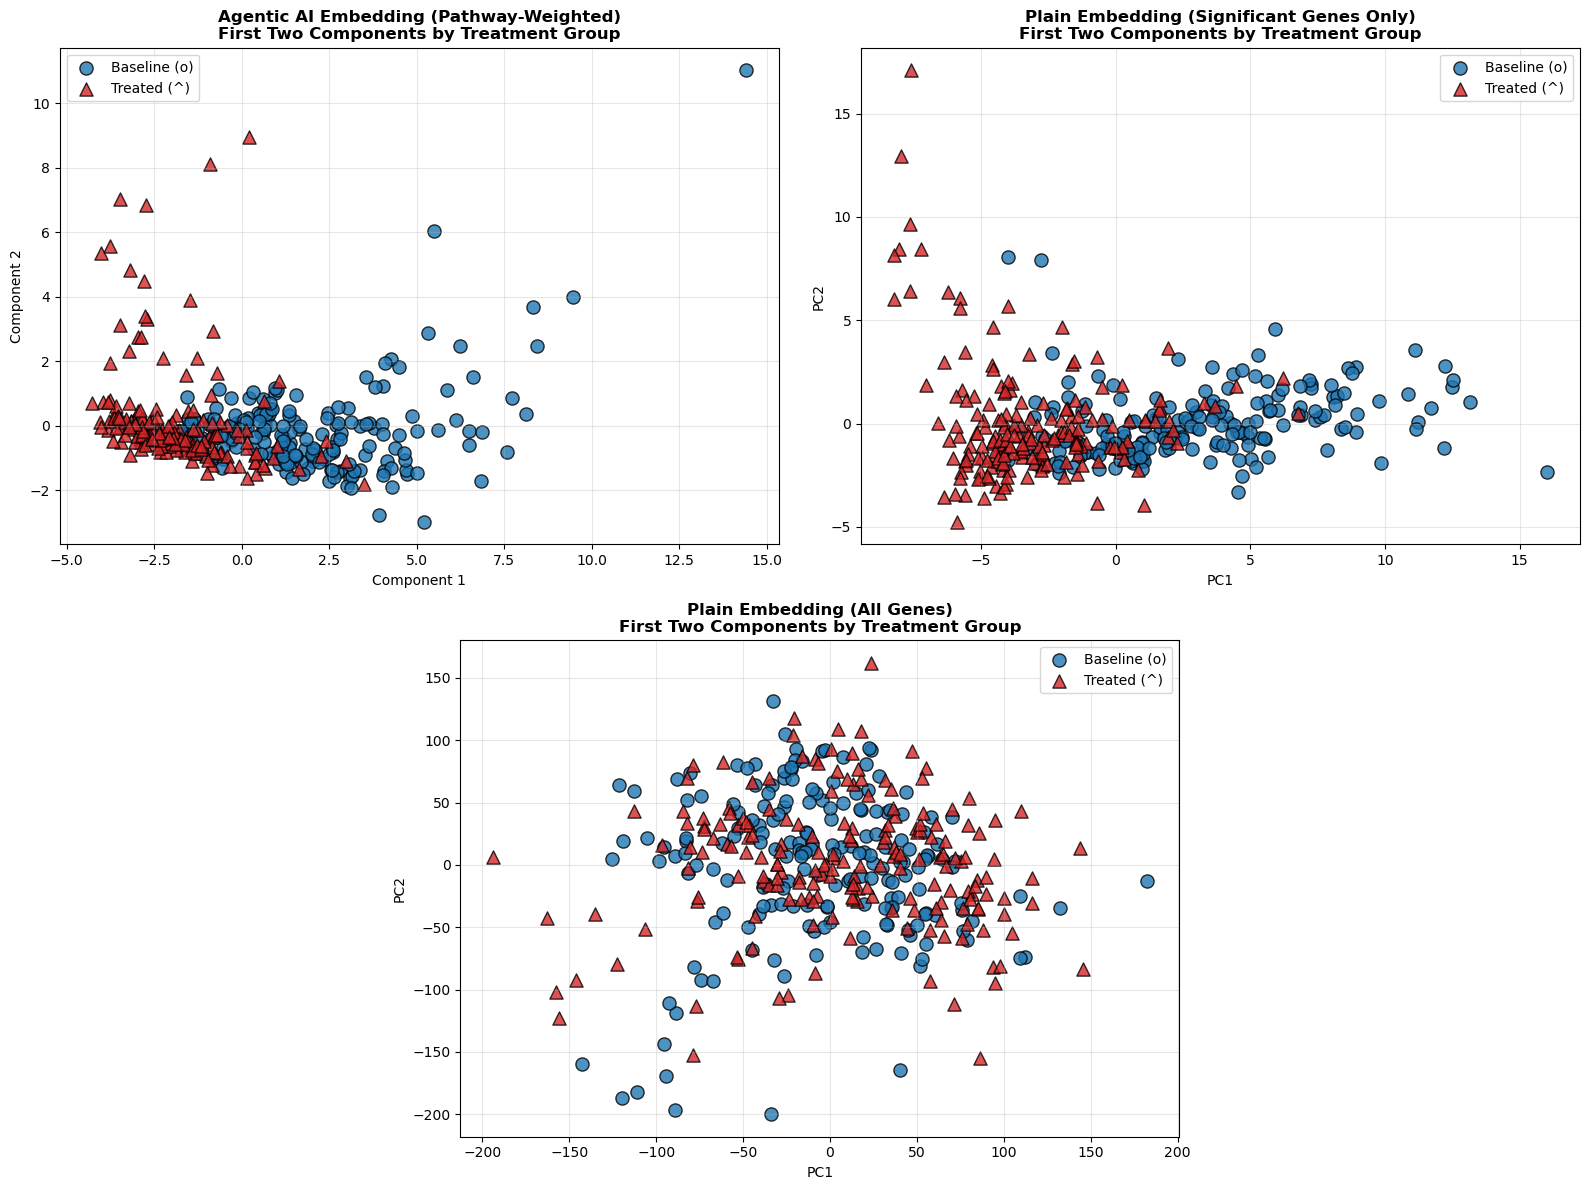

In [20]:
# Three scatter plots: Agentic AI (left), Plain Sig Genes (right), Plain All Genes (bottom center)
fig = plt.figure(figsize=(16, 12))

# Create custom subplot layout with bottom plot centered
# Using gridspec for better control
from matplotlib.gridspec import GridSpec

gs = GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])  # Top left (spans 2 columns)
ax2 = fig.add_subplot(gs[0, 2:4])  # Top right (spans 2 columns)
ax3 = fig.add_subplot(gs[1, 1:3])  # Bottom center (spans 2 columns, offset by 1)

# Plot 1: Agentic AI Embedding (top left)
df1 = df_ai_sig_embeddings
for group, color, marker, label in [(0, '#1f77b4', 'o', 'Baseline'), (1, '#d62728', '^', 'Treated')]:
    mask = df1['group_0_1'] == group
    ax1.scatter(df1.loc[mask].iloc[:, 0], df1.loc[mask].iloc[:, 1], 
               c=color, marker=marker, label=f'{label} ({marker})', 
               alpha=0.8, s=90, edgecolors='black', linewidth=1.0)
ax1.set_title('Agentic AI Embedding (Pathway-Weighted)\nFirst Two Components by Treatment Group', fontweight='bold')
ax1.set_xlabel('Component 1')
ax1.set_ylabel('Component 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Plain Embedding (Sig Genes) (top right)
df2 = df_sig_plain_embeddings
for group, color, marker, label in [(0, '#1f77b4', 'o', 'Baseline'), (1, '#d62728', '^', 'Treated')]:
    mask = df2['group_0_1'] == group
    ax2.scatter(df2.loc[mask, 'PC1'], df2.loc[mask, 'PC2'], 
               c=color, marker=marker, label=f'{label} ({marker})', 
               alpha=0.8, s=90, edgecolors='black', linewidth=1.0)
ax2.set_title('Plain Embedding (Significant Genes Only)\nFirst Two Components by Treatment Group', fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Plain Embedding (All Genes) (bottom center)
df3 = df_plain_embeddings
for group, color, marker, label in [(0, '#1f77b4', 'o', 'Baseline'), (1, '#d62728', '^', 'Treated')]:
    mask = df3['group_0_1'] == group
    ax3.scatter(df3.loc[mask, 'PC1'], df3.loc[mask, 'PC2'], 
               c=color, marker=marker, label=f'{label} ({marker})', 
               alpha=0.8, s=90, edgecolors='black', linewidth=1.0)
ax3.set_title('Plain Embedding (All Genes)\nFirst Two Components by Treatment Group', fontweight='bold')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()